In [ ]:
!pip install gymnasium[atari,accept-rom-license] stable-baselines3 shimmy
!pip install opencv-python

In [3]:
import os
import gymnasium as gym
import ale_py
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback

# 1. SETUP ENVIRONMENT
def make_env():
    # 'full_action_space=False' focuses on [NOOP, UP, DOWN]
    env = gym.make("ALE/Freeway-v5", render_mode="rgb_array", full_action_space=False)
    # Preprocessing (Level 4): MaxAndSkip, Grayscale, Resize 84x84
    env = AtariWrapper(env) 
    return env

# Vectorize
env = DummyVecEnv([make_env])

# 2. DIRECTORY FOR SAVES
save_path = "./freeway_model_1/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 3. MODEL 1 CONFIGURATION (Simplified)
model_1 = DQN(
    "CnnPolicy", 
    env, 
    verbose=0,                 # Keep 0 for the progress bar
    buffer_size=100000,        # RUBRIC REQ: 100k data points
    learning_rate=1e-4,
    batch_size=32,
    device="auto"              # Auto-detects your GTX 1660
)

# 4. CHECKPOINT CALLBACK
checkpoint_callback = CheckpointCallback(
    save_freq=10000, 
    save_path=save_path, 
    name_prefix="model1_baseline"
)

# 5. START TRAINING
print("🚀 Training Model 1... (Live Progress Bar Enabled)")
try:
    model_1.learn(
        total_timesteps=200000, 
        callback=checkpoint_callback,
        progress_bar=True      # Live visual update
    )
    
    # 6. SAVE FINAL MODEL
    model_1.save(os.path.join(save_path, "model_1_final"))
    print(f"\n✅ Success! Model 1 saved in {save_path}")
    
except KeyboardInterrupt:
    print("\n⏹️ Training paused. Progress saved.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

🚀 Training Model 1... (Live Progress Bar Enabled)


Output()


✅ Success! Model 1 saved in ./freeway_model_1/


In [4]:
import gymnasium as gym
import ale_py
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper


gym.register_envs(ale_py)  # Explicitly registers the ALE namespace
env = gym.make('ALE/Breakout-v5')


# 1. Load the saved "Simple" Brain
# Make sure this path matches your 'save_path' from the previous cell
model_path = "./freeway_model_1/model_1_final.zip"
model_1 = DQN.load(model_path)

# 2. Create the environment for a Live Demo
env = gym.make("ALE/Freeway-v5", render_mode="human", full_action_space=False)
env = AtariWrapper(env)

# 3. Run one evaluation game
obs, info = env.reset()
done = False
while not done:
    # Use 'deterministic=True' for the best performance during the demo
    action, _states = model_1.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()
print("🎬 Demo Complete. Note how it handles the fast cars (top lanes).")

🎬 Demo Complete. Note how it handles the fast cars (top lanes).


📊 Starting Level 4 Evaluation for Model 1...
Episode    | Crossings  | Time (s)   | Sec/Cross 
--------------------------------------------------
1          | 25.0       | 2.50       | 0.10      
2          | 24.0       | 3.42       | 0.14      
3          | 23.0       | 4.54       | 0.20      
4          | 23.0       | 5.78       | 0.25      
5          | 24.0       | 5.24       | 0.22      
6          | 24.0       | 6.05       | 0.25      
7          | 24.0       | 6.78       | 0.28      
8          | 26.0       | 6.23       | 0.24      
9          | 25.0       | 5.20       | 0.21      
10         | 23.0       | 5.43       | 0.24      
11         | 24.0       | 5.50       | 0.23      
12         | 22.0       | 6.42       | 0.29      
13         | 25.0       | 4.63       | 0.19      
14         | 25.0       | 4.17       | 0.17      
15         | 22.0       | 5.14       | 0.23      
16         | 28.0       | 5.32       | 0.19      
17         | 22.0       | 4.31       | 0.20      
18  

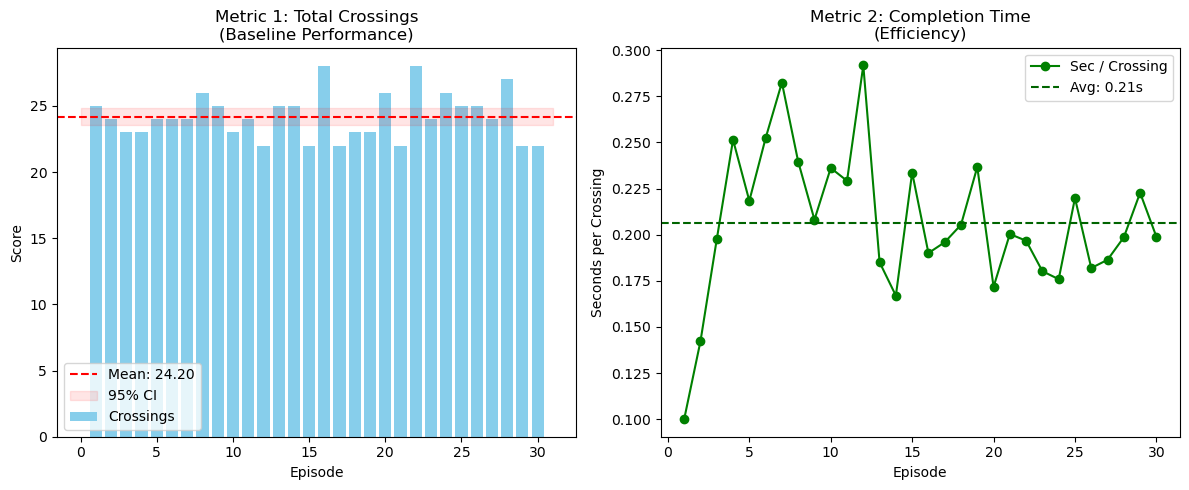


LEVEL 4 SUMMARY STATISTICS
Mean Score (μ): 24.20
Standard Deviation (σ): 1.73
95% Confidence Interval: [23.58, 24.82]
Mean Time Per Crossing: 0.21 seconds


In [2]:
import os
import gymnasium as gym
import ale_py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper

# 1. LOAD MODEL & ENVIRONMENT
model_path = "./freeway_model_1/model_1_final"
model = DQN.load(model_path)
env = gym.make("ALE/Freeway-v5", render_mode="rgb_array", full_action_space=False)
env = AtariWrapper(env)

num_episodes = 30
episode_data = []

print(f"📊 Starting Level 4 Evaluation for Model 1...")
print(f"{'Episode':<10} | {'Crossings':<10} | {'Time (s)':<10} | {'Sec/Cross':<10}")
print("-" * 50)

for i in range(num_episodes):
    obs, info = env.reset()
    done = False
    score = 0
    start_time = time.time()
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated
    
    duration = time.time() - start_time
    # Metric 2: Speed (Lower is better)
    time_per_cross = duration / score if score > 0 else 126.0
    
    # PRINTING DATA DIRECTLY TO OUTPUT
    print(f"{i+1:<10} | {score:<10} | {duration:<10.2f} | {time_per_cross:<10.2f}")
    
    episode_data.append({
        'Episode': i + 1,
        'Score': score,
        'Time_Per_Cross': time_per_cross
    })

df = pd.DataFrame(episode_data)

# --- CALCULATE STATS FOR RUBRIC ---
mean_r = df['Score'].mean()
std_r = df['Score'].std()
ci_margin = 1.96 * (std_r / np.sqrt(num_episodes))
mean_speed = df['Time_Per_Cross'].mean()

# --- GRAPH 1: RE-ADDING THE BASELINE PERFORMANCE ---
plt.figure(figsize=(12, 5))

# Subplot 1: Total Crossings (Score)
plt.subplot(1, 2, 1)
plt.bar(df['Episode'], df['Score'], color='skyblue', label='Crossings')
plt.axhline(y=mean_r, color='red', linestyle='--', label=f'Mean: {mean_r:.2f}')
plt.fill_between(range(0, 32), mean_r - ci_margin, mean_r + ci_margin, color='red', alpha=0.1, label='95% CI')
plt.title('Metric 1: Total Crossings\n(Baseline Performance)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()

# Subplot 2: Efficiency (Time)
plt.subplot(1, 2, 2)
plt.plot(df['Episode'], df['Time_Per_Cross'], marker='o', color='green', label='Sec / Crossing')
plt.axhline(y=mean_speed, color='darkgreen', linestyle='--', label=f'Avg: {mean_speed:.2f}s')
plt.title('Metric 2: Completion Time\n(Efficiency)')
plt.xlabel('Episode')
plt.ylabel('Seconds per Crossing')
plt.legend()

plt.tight_layout()
plt.show()

# --- FINAL TEXT OUTPUT FOR SLIDES ---
print("\n" + "="*30)
print("LEVEL 4 SUMMARY STATISTICS")
print("="*30)
print(f"Mean Score (μ): {mean_r:.2f}")
print(f"Standard Deviation (σ): {std_r:.2f}")
print(f"95% Confidence Interval: [{mean_r - ci_margin:.2f}, {mean_r + ci_margin:.2f}]")
print(f"Mean Time Per Crossing: {mean_speed:.2f} seconds")
print("="*30)